# **Global Emissions and Economic Growth: Implications for Climate Finance and Transition Pathways.**

**Introduction**

Understanding the relationship between economic growth and carbon emissions is critical for informing climate policy and financial decision-making. This project analyses global CO₂ emissions data to explore how emissions evolve alongside economic development across countries at different stages of transition.

Using a dataset from Our World in Data, this analysis compares developed, emerging, and transitional economies to identify patterns in emissions intensity and potential evidence of decoupling between GDP growth and emissions.

The findings provide insights into how countries are progressing along different transition pathways and highlight implications for climate finance allocation and net-zero strategies.

The analysis aims to provide insights relevant for climate finance allocation, highlighting where emissions reductions are occuring alongside economic growth and whee further policy intervention may be required.

# **Methodology**

This project follows a structured data analysis pipeline:

1. Data Ingestion
- Loaded global emissions dataset from a public GitHub source using Python (pandas).

2. Data Cleaning
- Handled missing values by removing incomplete observations for key variables (GDP and CO₂)
- Filtered dataset to post-1990 period for policy relevance.

3. Feature Selection
- Selected core variables relevant to climate-economic analysis:
GDP (economic output)
CO₂ emissions (environmental impact)
Additional indicators (e.g., population, energy use) retained for potential extension

4. Country Selection
Selected representative countries across different development stages:
-Advanced economies (e.g., UK, Germany, US)
-Emerging economies (e.g., China, India, Brazil)
-Transitional economies (e.g., South Africa).                                     This enables comparison of different decarbonisation pathways

5. Data Transformation
- Applied log transformation to GDP and CO₂ variables to:
i) Reduce skewness from large economies
ii) Enable proportional (elasticity-based) interpretation of relationships

6. Analysis
- Examined relationships between economic growth and emissions.
- Compared patterns across countries to identify divergence in transition pathways.

7. Visualisation
- Generated scatter plots and log-log plots
- Applied regression lines to identify trends and strength of relationships

8. Insight Generation
- Interpreted results in the context of climate policy and finance context
- Identified evidence of:
*   Emissions-growth coupling
*   Partial decoupling
*   Structural transition differences across economies


**Data Source**

- Dataset: Global CO₂ and energy data
- Source: Our World in Data
- Accessed via GitHub (raw CSV link for reproducibility)

In [ ]:
import pandas as pd
url ="https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(50411, 79)

In [ ]:
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

Feature Selection

In [ ]:
cols = ['country', 'year', 'co2', 'co2_per_capita', 'gdp', 'population', 'energy_per_capita']
df = df[cols]

**Clean data.**

In [ ]:
df = df.dropna()

df = df[df['year'] >= 1990]

**Filtering Key countries.**

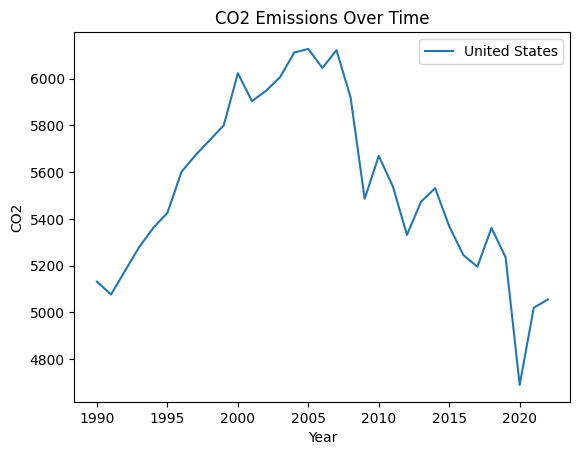

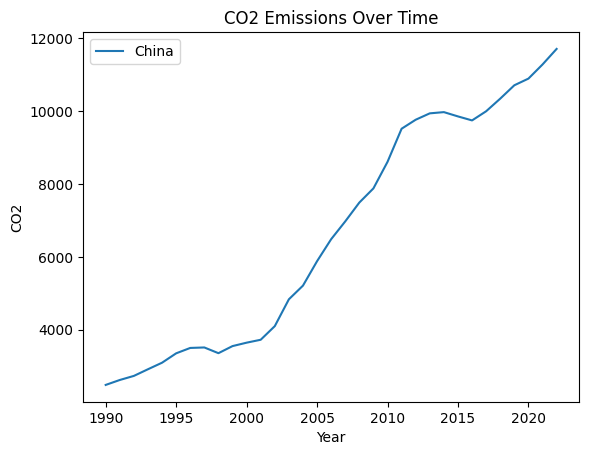

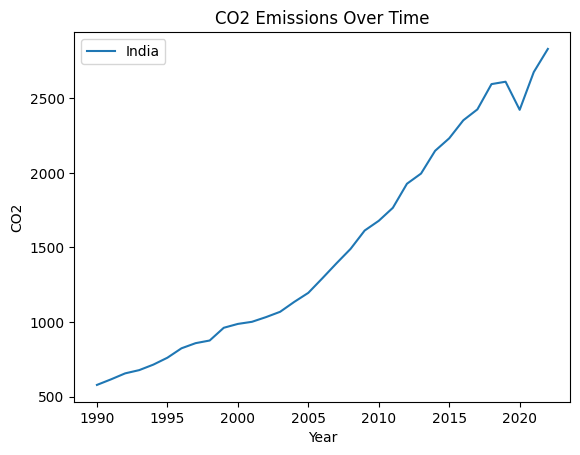

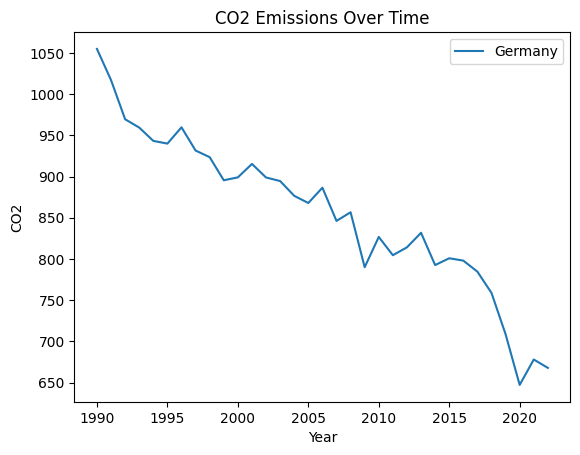

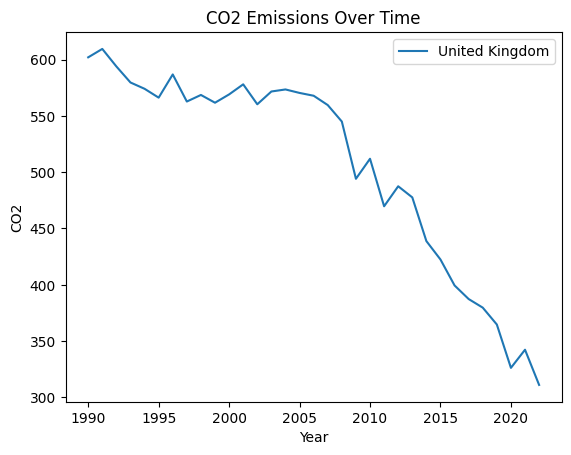

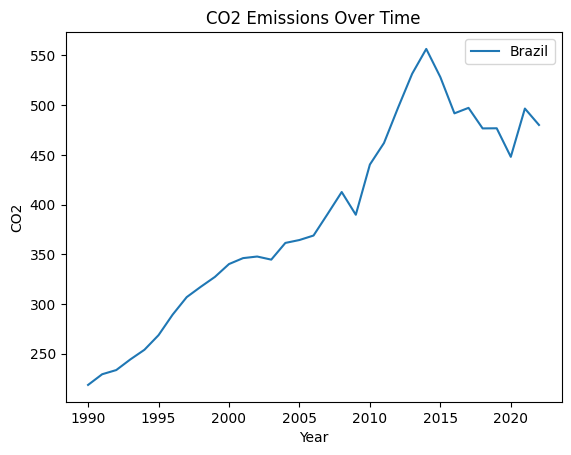

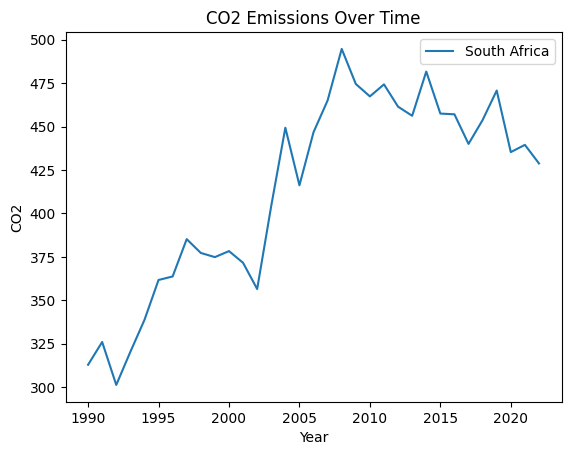

In [ ]:
import matplotlib.pyplot as plt

countries = ['United States', 'China', 'India', 'Germany', 'United Kingdom', 'Brazil', 'South Africa']

for c in countries:
  temp = df[df['country'] == c]
  plt.plot(temp['year'], temp['co2'], label=c)
  plt.legend()
  plt.title('CO2 Emissions Over Time')
  plt.xlabel('Year')
  plt.ylabel('CO2')
  plt.show()

comment on graph above for selected countries.

The charts show that CO2 emissions trends differ significantly across countries from 1990 to 2022. China records the steepest and most sustained increase, with emissions rising sharply over time, indicating that economic growth has remained closely tied to carbon-intensive industrial expansion. India also shows a strong upward trend, though at a lower level than China, suggesting that emissions continue to rise alongside development and industrialisation.

The United States follows a different path: emissions rise until the mid-2000s, then trend downward overall despite fluctuations, including a sharp dip around 2020 and a modest rebound afterwards. This suggests some degree of decoupling between economic growth and emissions. Germany and the United Kingdom show the clearest long-term declines, reflecting sustained reductions over time. The UK in particular shows a pronounced downward trajectory, indicating one of the strongest proportional improvements among the countries shown.

Brazil shows a moderate but important pattern. Emissions rise steadily from the early 1990s to a peak in the mid-2010s, after which they ease back and fluctuate at a slightly lower level. This suggests that Brazil experienced a long period of emissions growth, but more recently has shown signs of stabilisation rather than continued rapid increase. South Africa shows a more volatile pattern: emissions rise overall through the 1990s and 2000s, reach a peak around the late 2000s, and then broadly plateau or decline slightly in later years. Compared with China and India, South Africa’s emissions growth appears more constrained, but unlike Germany or the UK, it has not achieved a strong sustained downward trend.

Overall, the data suggests three broad groups. First, countries such as China and India are still on a rising emissions path. Second, the United States, Brazil, and South Africa show more mixed or transitional patterns, with emissions either peaking, stabilising, or declining only gradually. Third, Germany and the United Kingdom demonstrate clearer long-term reductions. The key message is that emissions transitions are happening at very different speeds, and global progress will depend not only on continued reductions in advanced economies, but also on whether large and emerging economies can shift onto lower-carbon growth paths.

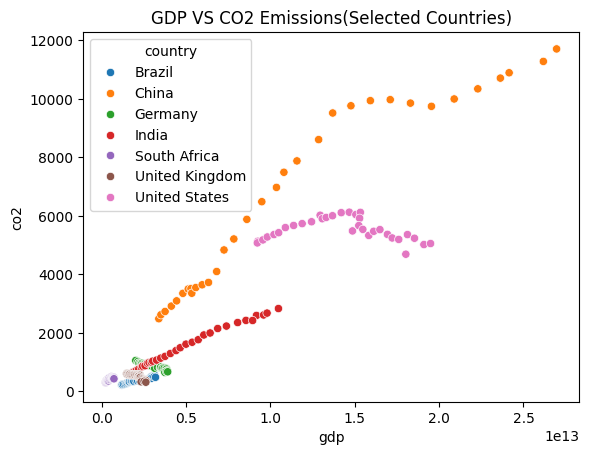

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
countries = ['United Kingdom', 'Germany', 'India', 'United States', 'China', 'Brazil', 'South Africa']
df_filtered = df[df['country'].isin(countries)]

sns.scatterplot(data=df_filtered, x='gdp', y='co2', hue='country')
plt.title('GDP VS CO2 Emissions(Selected Countries)')
plt.show()

The scatter plot compares GDP and CO2 emissions across seven countries and shows that the relationship between economic growth and emissions differs markedly by country. Overall, the chart suggests that higher GDP does not always lead to proportionally higher emissions, and that countries are at very different stages of the transition from carbon-intensive growth to lower-carbon development.

China shows the strongest positive relationship between GDP and CO2 emissions. As GDP increases, emissions rise sharply and remain at the highest level among all countries shown. This indicates that economic expansion has been closely tied to energy-intensive and industrial activity, with only limited evidence of full decoupling so far.

India also shows a clear upward pattern, with emissions steadily increasing alongside GDP. Although India operates at lower absolute GDP and emissions levels than China, the trajectory suggests that growth is still closely linked to higher carbon output. For stakeholders, this signals that future global emissions will depend heavily on how fast cleaner energy and industrial transitions can scale in emerging economies.

The United States presents a different profile. At high GDP levels, emissions initially rise, then flatten, and later begin to decline while GDP remains strong. This is a clear sign of partial decoupling: the economy continues to grow, but emissions fall over time. This may reflect changes in energy mix, efficiency improvements, and a shift toward less carbon-intensive sectors.

Germany and the United Kingdom show the clearest examples of stronger decoupling. Both countries appear at relatively moderate GDP levels but with declining or comparatively low emissions. Their patterns suggest that economic activity has been maintained while emissions have gradually fallen, indicating more mature low-carbon transition pathways. The UK appears especially low-emitting relative to GDP among the countries shown.

Brazil sits in the mid-range, with GDP growth associated with a moderate increase in emissions. However, the spread of points suggests a less steep relationship than China or India. This implies that while growth has involved rising emissions, the carbon intensity of that growth has been less extreme. It may also suggest some stabilisation in later periods rather than uninterrupted emissions growth.

South Africa shows a smaller GDP base but relatively elevated emissions compared with economies of similar size in the chart. The pattern is more clustered and somewhat uneven, suggesting slower GDP expansion with emissions remaining comparatively high. This may indicate structural dependence on carbon-intensive energy sources and more limited progress in decoupling.

The scatter plot highlights three broad carbon-growth patterns:

1. Growth still strongly linked to emissions: China and India
2. Transitional decoupling: United States, Brazil, South Africa
3. Stronger decoupling: Germany and United Kingdom

The key strategic message is that economic growth and emissions are no longer moving together in the same way across all countries. Some economies have started to separate GDP growth from CO2 growth, while others are still on emissions-intensive development paths. This matters for policy, investment, and sustainability planning because it shows where transition risk is likely to remain highest and where lower-carbon growth models appear more established.

**Log–Log Transformation and Comparative Analysis of GDP and CO2 Emissions.**

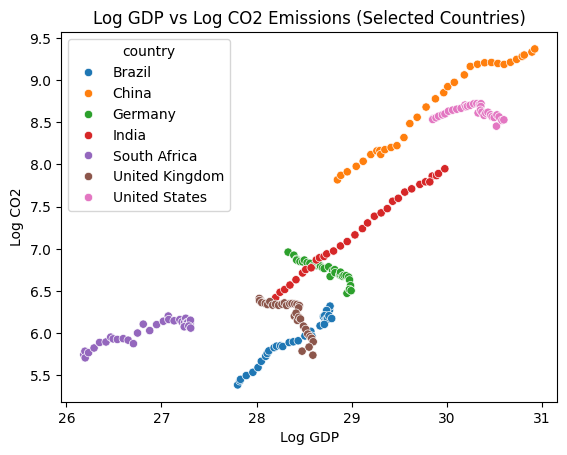

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered = df_filtered.copy()
df_filtered['log_gdp'] = np.log(df_filtered['gdp'])
df_filtered['log_co2'] = np.log(df_filtered['co2'])

sns.scatterplot(data=df_filtered, x='log_gdp', y='log_co2', hue='country')
plt.title('Log GDP vs Log CO2 Emissions (Selected Countries)')
plt.xlabel('Log GDP')
plt.ylabel('Log CO2')
plt.show()

Comment on results

The log-log scatter plot makes the relationship between GDP and CO2 emissions much clearer across countries because both variables have been rescaled. Compared with the raw-value scatter plot, the data points are less compressed by very large economies, so country-specific patterns are easier to identify.

The plot shows that the relationship between economic output and emissions remains positive overall, but the strength and shape of that relationship differ by country.

China shows a strong upward pattern, indicating that as GDP increases, CO2 emissions also rise substantially. This suggests continued dependence on carbon-intensive growth.
India also shows a clear and fairly linear upward relationship, indicating that economic expansion is still closely associated with rising emissions.
United States shows a flatter, curved pattern at high GDP levels. Emissions rise up to a point, then stabilise and begin to ease slightly, which suggests partial decoupling.
Germany shows a downward-sloping pattern, meaning emissions fall as GDP remains relatively strong. This is a clear sign of decoupling.
United Kingdom also shows a downward trend, with CO2 decreasing as GDP changes more modestly, again indicating stronger decoupling.
Brazil shows a moderate upward relationship, suggesting emissions have increased with growth, but less sharply than in China or India.
South Africa appears more clustered, with smaller GDP variation and only modest change in emissions, suggesting slower growth and a less dynamic but still carbon-intensive structure.
Analysis

This transformation is useful because a log-log plot improves interpretation in three ways.

First, it reduces skewness in the data. GDP and CO2 values vary greatly across countries, and using logs compresses extreme values so smaller economies are not visually dominated by larger ones.

Second, it helps reveal whether relationships are approximately linear in proportional terms. In this case, several countries, especially China and India, show fairly linear upward patterns on the log-log scale. That suggests a relatively stable proportional relationship between GDP growth and emissions growth.

Third, it makes decoupling easier to detect. Countries such as Germany and the United Kingdom show downward-sloping or weakening relationships, meaning economic activity is being maintained or expanded while emissions fall. The United States appears to sit between the two groups, showing some decoupling but not as strongly as Germany or the UK.

Interpretation for stakeholders

The key message is that countries are not following the same development path.

China and India are still on a growth path where higher GDP is closely linked to higher emissions.
The United States shows evidence of transition, where growth is continuing but emissions are no longer increasing at the same rate.
Germany and the United Kingdom show the strongest evidence that growth can be achieved alongside falling emissions.
Brazil and South Africa sit in the middle, with more mixed or moderate patterns.

**Log–Log Regression Analysis of GDP and CO2 Emissions by Country**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lmplot(data=df_filtered, x='log_gdp', y='log_co2', hue='country', height=6, aspect=1.5)
plt.title('Log GDP vs Log CO2 Emissions (Selected Countries)')
plt.xlabel('Log GDP')
plt.ylabel('Log CO2')
plt.show()

**Comment on results**

Key Insights from Log-Log Analysis
The log-log transformation allows interpretation in percentage terms, where the slope represents how CO2 emissions change relative to GDP growth.
*   China and India show strong positive relationships, indicating emissions increase rapidly with economic growth.
*   The United States shows a flatter trend, suggesting partial decoupling at higher income levels.
*   Germany and the United Kingdom display downward or weakening relationships, indicating stronger decoupling between economic growth and emissions.
*   Brazil shows a moderate positive relationship, where emissions rise with GDP but less steeply than in China and India.
*   South Africa appears more clustered with a weaker upward trend, indicating slower growth and a less dynamic but still carbon-intensive structure.



**Policy Interpretation and Climate Finance Implications**

The results highlight that countries are following distinct carbon transition pathways, with important implications for climate finance allocation and policy design.
High carbon-growth dependency (China, India)
These countries exhibit strong positive log-log relationships, indicating that emissions increase proportionally with economic growth. This suggests continued reliance on carbon-intensive energy systems.
From a climate finance perspective, this implies a need for large-scale capital mobilisation toward renewable energy, grid infrastructure, and industrial decarbonisation.

**Partial decoupling (United States)**
The flatter relationship at higher GDP levels suggests that emissions growth is slowing relative to economic expansion.
This reflects the impact of technological innovation, policy incentives, and energy transition, but also indicates that further investment is required to achieve full decoupling.

**Strong decoupling (Germany, United Kingdom)**
Negative or weakening relationships indicate that emissions are stabilising or declining despite continued economic growth.
1. These countries represent mature transition pathways, where policy frameworks, carbon pricing, and clean energy adoption have successfully reduced emissions intensity.
2. Climate finance here shifts toward innovation, efficiency, and maintaining net-zero trajectories.

**Transitional economies (Brazil, South Africa)**
These countries show moderate or weaker relationships, with emissions rising more slowly relative to GDP or remaining clustered.
1. This suggests structural constraints, such as energy system rigidity, reliance on specific sectors, or limited investment capacity.
2. Targeted climate finance is needed to support just transitions, infrastructure upgrades, and sector-specific decarbonisation.

**Cross-Country Insights for Climate Policy**



*   The variation in slopes demonstrates that economic growth does not inherently require increased emissions, but depends on energy systems, policy, and investment.
*   Countries appear to fall into three transition categories:
a). Carbon-intensive growth (China, India)
b). Transitional or mixed pathways (Brazil, South Africa, United States)
c). Decoupled growth (Germany, United Kingdom)

**Implications for Climate Finance Tracking.**

1. These findings support the need for differentiated climate finance strategies, rather than a one-size-fits-all approach.
2. Emerging economies require scaled financing flows to shift development pathways away from carbon-intensive growth.
3. Advanced economies demonstrate that policy + investment alignment can enable decoupling, providing models for replication.
4. Data-driven approaches like this can support tracking progress toward net-zero commitments, identifying where financial flows are most urgently needed.